# MMTFv3 CL+GC PPO on V3Continuous Environment

Trains a **PPO** agent with a `V3ContinuousExtractor` that mirrors the full
**MMTFv3Core** architecture:

## Architecture (matches supervised MMTFv3Core)
1. **Phase 0**: VAE on `ae_input` -> `z_regime` (regime latent)
2. **Phase 1**: `AutoencoderConditionedEncoder(identity + z_regime)` -> `c_s, c_e, c_c, c_h`
3. **Phase 2**: Tech features -> projection + regime enrichment -> Mamba/Transformer backbone -> `(fused_seq, fused_token)`
4. **Phase 3**: Spatial (NumberBars + VPIN raster -> SpatialFuse) + Sequential (tabular VPIN -> IntradayRNN)
5. **Phase 4**: `BranchVariableSelection([fused_token, z_spatial, z_seq], context=c_s)` -> `z_selected`
6. **Phase 5**: Enrichment + Temporal Attention -> `z_temporal`
7. **Output**: `cat[z_temporal, z_selected]` -> PPO actor-critic heads

## RL Stack
- `V3ContinuousPrep.build_samples(...)` -> bar-level multi-modal samples
- `V3ContinuousPPOEnv` -> Gymnasium environment
- `V3ContinuousExtractor` -> SB3 `BaseFeaturesExtractor` (full MMTFv3 pipeline)
- `PPO("MultiInputPolicy", ...)` -> actor-critic agent
- **Optuna** -> hyperparameter optimization

## Action and Reward
- Action space: `0=Short (-1), 1=Flat (0), 2=Long (+1)`
- Reward: `(prev_position * forward_return - tc * |delta_position|) * reward_scale`
- Position tracked independently per ticker


## 1. Environment Setup

In [1]:
# Mount Google Drive (Colab only)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print("Not running in Colab - skipping drive mount")

Not running in Colab - skipping drive mount


In [2]:
# Add CTAFlow to path (Colab only)
if IN_COLAB:
    import sys
    %cd /content/drive/MyDrive/CTAEnv/
    %cd CTAFlow
    !git pull
    %cd ..
    sys.path.insert(0, '/content/drive/MyDrive/CTAEnv/CTAFlow/')
    sys.path.insert(1, '/content/drive/MyDrive/CTAEnv/SierraPy')
    !pip install -e SierraPy -q
    !pip install -e CTAFlow -q
    !pip install optuna -q
else:
    print("Running locally - ensure CTAFlow and optuna are installed")

Running locally - ensure CTAFlow and optuna are installed


In [3]:
import json
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")
print(f"Optuna version: {optuna.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.4.1+cu124
Optuna version: 4.7.0
CUDA available: True
CUDA device: NVIDIA GeForce RTX 4090


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

Using device: cuda


## 2. Configuration

In [5]:
# --- Tickers ---
TICKERS = ['CL', 'GC']

# --- Architecture ---
TUNE_BACKBONE = False     # Let Optuna choose mamba/transformer
BACKBONE = 'mamba'       # Default if TUNE_BACKBONE=False

# --- Target ---
TARGET_HORIZON_MINUTES = 30   # 30min forward return
BAR_MINUTES = 5               # 5min bars → target = y_fwd_6

# --- Session Filter ---
# Options:
#   SAMPLE_SESSION = "usa"                     # Named: "usa", "london", "overlap"
#   SAMPLE_SESSION = None                      # Use all active session bars
#   SAMPLE_SESSION_START/END = "09:30"/"15:00" # Custom time window
SAMPLE_SESSION = "overlap"              # Filter to USA session only
SAMPLE_SESSION_START = None         # Custom start (overrides SAMPLE_SESSION if both set)
SAMPLE_SESSION_END = None           # Custom end

# --- Stride ---
# stride=6 with 5min bars + 30min target → non-overlapping samples
# stride=3 → 50% overlap, stride=1 → every bar (max overlap)
SAMPLE_STRIDE = 6

# --- AE ---
AE_WINDOW = 21                # 21 trading days lookback for regime VAE
F_AE = 4                      # [ret_1d, ret_5d, ret_21d, rv_1d]

# --- Paths ---
if IN_COLAB:
    DRIVE_PATH = Path('/content/drive/MyDrive')
    DATA_ROOT = DRIVE_PATH / 'features'
    RESULTS_PATH = DRIVE_PATH / 'results' / 'mmtfv3_cl_gc'
else:
    DATA_ROOT = Path('/workspace/model_data')
    RESULTS_PATH = Path('/workspace/results/mmtfv3_cl_gc')

RESULTS_PATH.mkdir(parents=True, exist_ok=True)

print(f"Data root: {DATA_ROOT}")
print(f"Results path: {RESULTS_PATH}")
print(f"Tickers: {TICKERS}")
print(f"Target: {TARGET_HORIZON_MINUTES}min forward return")
if SAMPLE_SESSION_START and SAMPLE_SESSION_END:
    print(f"Session filter: custom {SAMPLE_SESSION_START}-{SAMPLE_SESSION_END}")
elif SAMPLE_SESSION:
    print(f"Session filter: {SAMPLE_SESSION.upper()}")
else:
    print(f"Session filter: all active bars")
print(f"Stride: {SAMPLE_STRIDE} bars ({SAMPLE_STRIDE * BAR_MINUTES}min between samples)")
print(f"AE window: {AE_WINDOW} days, f_ae={F_AE}")
if TUNE_BACKBONE:
    print(f"Backbone: Optuna-tuned (mamba / transformer)")
else:
    print(f"Backbone: {BACKBONE.upper()} (fixed)")

Data root: /workspace/model_data
Results path: /workspace/results/mmtfv3_cl_gc
Tickers: ['CL', 'GC']
Target: 30min forward return
Session filter: OVERLAP
Stride: 6 bars (30min between samples)
AE window: 21 days, f_ae=4
Backbone: MAMBA (fixed)


In [6]:
# Verify data files for each ticker
print("Checking data files...")
required_files = ['intraday.csv', 'profiles.npz', 'rasterized.npz', 'vpin.parquet']

all_found = True
for ticker in TICKERS:
    ticker_path = DATA_ROOT / ticker
    print(f"\n{ticker}:")
    for fname in required_files:
        fpath = ticker_path / fname
        status = "[OK]" if fpath.exists() else "[MISSING]"
        print(f"  {status} {fname}")
        if not fpath.exists():
            all_found = False

if not all_found:
    print("\n[WARNING] Some files missing - data loading may fail")

Checking data files...

CL:
  [OK] intraday.csv
  [OK] profiles.npz
  [OK] rasterized.npz
  [OK] vpin.parquet

GC:
  [OK] intraday.csv
  [OK] profiles.npz
  [OK] rasterized.npz
  [OK] vpin.parquet


## 3. Load Data via V3ContinuousPrep

In [11]:
from CTAFlow.data.datasets.v3_continuous import (
    V3ContinuousPrep,
    V3ContinuousDataset,
    v3_collate_fn,
    unpack_v3_batch,
    build_v3_loaders,
)
from CTAFlow.models.prep.intraday_continuous import SessionSpec

print("Loading ticker data...")
prep = V3ContinuousPrep.from_directories(
    root_dir=DATA_ROOT,
    tickers=TICKERS,
    sessions=[SessionSpec("both", "08:30", "11:00")],
    bar_minutes=BAR_MINUTES,
    target_horizon_minutes=TARGET_HORIZON_MINUTES,
    ae_window=AE_WINDOW,
)

dims = prep.get_dims()
print(f"\nFeature dimensions: {dims}")
print(f"Tech feature columns ({dims['f_tech']}): {prep._tech_feature_cols[:10]}...")
print(f"n_tickers: {prep.n_tickers}")
print(f"n_asset_classes: {prep.n_asset_classes}")
print(f"n_asset_subclasses: {prep.n_asset_subclasses}")

Loading ticker data...
  [CL] 131419 valid bars, profiles=3641, rasters=3627, ae_dates=4239, vpin_cols=21
  [GC] 130469 valid bars, profiles=3874, rasters=3821, ae_dates=4209, vpin_cols=21
  Spatial shapes: profile=(4, 96), raster=(12, 4, 128)

Feature dimensions: {'f_tech': 42, 'f_seq': 21, 'f_ae': 4, 'numbars_channels': 4, 'vpin_time': 12, 'vpin_channels': 4, 'vpin_bins': 128}
Tech feature columns (42): ['tod_slot', 'session_code', 'is_active', 'is_london', 'is_usa', 'is_session_overlap', 'tod_sin', 'tod_cos', 'dow_sin', 'dow_cos']...
n_tickers: 2
n_asset_classes: 1
n_asset_subclasses: 3


tod_sin confirmed in feature columns
CL: mean=-0.000001, std=0.003862, n=1168272
GC: mean=0.000008, std=0.001455, n=1162524


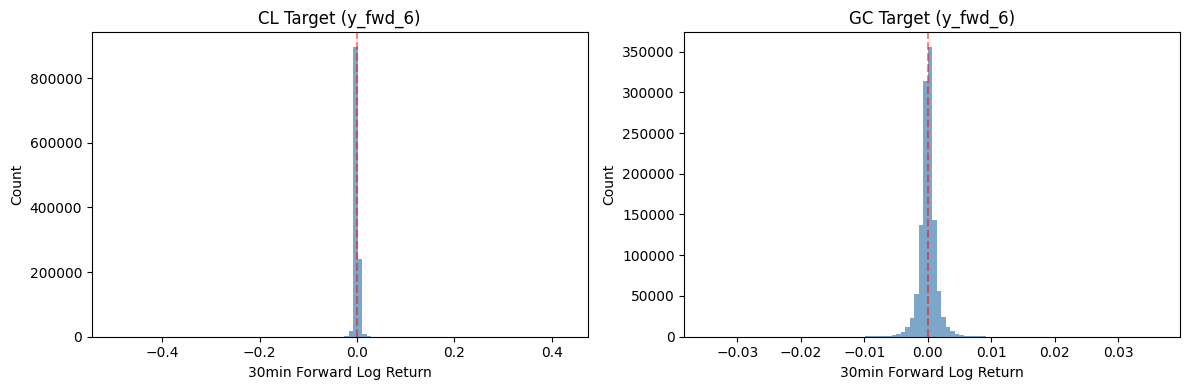

In [12]:
# Verify tech features include tod_sin
assert 'tod_sin' in prep._tech_feature_cols, "tod_sin missing from feature cols!"
print("tod_sin confirmed in feature columns")

# Quick target distribution check
fig, axes = plt.subplots(1, len(TICKERS), figsize=(6*len(TICKERS), 4))
if len(TICKERS) == 1:
    axes = [axes]

for ticker, ax in zip(TICKERS, axes):
    df = prep._tech_dfs.get(ticker)
    if df is None:
        continue
    target = df[prep._target_col].dropna()
    ax.hist(target.values, bins=100, alpha=0.7, color='steelblue')
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.5)
    ax.set_title(f'{ticker} Target ({prep._target_col})')
    ax.set_xlabel('30min Forward Log Return')
    ax.set_ylabel('Count')
    print(f"{ticker}: mean={target.mean():.6f}, std={target.std():.6f}, n={len(target)}")

plt.tight_layout()
plt.show()

## 4. Build RL Environments from V3ContinuousPrep


In [ ]:
from stable_baselines3 import PPO

from CTAFlow.models.deep_learning.rl import (
    V3ContinuousPPOEnv,
    build_v3_rl_envs,
    V3ContinuousExtractor,
    TradingMetricsCallback,
    EarlyStoppingCallback,
)

print('RL modules imported (env + extractor + PPO + TradingMetricsCallback + EarlyStoppingCallback)')


In [14]:
# RL environment configuration
TECH_LOOKBACK = 64
SEQ_LOOKBACK = 12
VAL_RATIO = 0.2
VAL_CUTOFF_DATE = None

TRANSACTION_COST_BPS = 1.0
REWARD_SCALE = 100.0
MAX_EPISODE_STEPS = None

train_env, val_env, env_info = build_v3_rl_envs(
    prep,
    tech_lookback=TECH_LOOKBACK,
    seq_lookback_bars=SEQ_LOOKBACK,
    val_ratio=VAL_RATIO,
    val_cutoff_date=VAL_CUTOFF_DATE,
    sample_session=SAMPLE_SESSION,
    sample_session_start=SAMPLE_SESSION_START,
    sample_session_end=SAMPLE_SESSION_END,
    stride=SAMPLE_STRIDE,
    transaction_cost_bps=TRANSACTION_COST_BPS,
    reward_scale=REWARD_SCALE,
    max_episode_steps=MAX_EPISODE_STEPS,
)

print('Built V3 RL environments')
print(f"  train_samples: {env_info['train_samples']}")
print(f"  val_samples:   {env_info['val_samples']}")
print(f"  cutoff_date:   {env_info['cutoff_date']}")
print(f"  n_tickers:     {env_info['n_tickers']}")
print(f"  obs_shapes:    {env_info['train_obs_shapes']}")



    [WARN] 'is_session_overlap' all-zero, falling back to is_active
  [CL] build_samples: total_bars=1168278, in_session=131419, with_target=131419, days_with_bars=4241, bars_after_stride=25434
    date_filters: no_prev=0, no_spatial=1371, ae_short=0, ae_missing=0, days_used=2870, samples_so_far=17217
    [WARN] 'is_session_overlap' all-zero, falling back to is_active
  [GC] build_samples: total_bars=1162530, in_session=130469, with_target=130469, days_with_bars=4212, bars_after_stride=25250
    date_filters: no_prev=0, no_spatial=1138, ae_short=0, ae_missing=0, days_used=3074, samples_so_far=35656
Built V3 RL environments
  train_samples: 28549
  val_samples:   7107
  cutoff_date:   2023-01-04
  n_tickers:     2
  obs_shapes:    {'ae_input': (21, 4), 'asset_class_id': (1,), 'asset_subclass_id': (1,), 'numbars_recent': (1, 96, 4), 'seq_vpin': (12, 21), 'seq_vpin_lens': (1,), 'tech_features': (64, 42), 'tech_lens': (1,), 'ticker_id': (1,), 'vpin_raster_recent': (12, 4, 128)}


In [15]:
# --- Sanity check: run one forward pass on CPU to catch errors with traceback ---
# CUDA errors are async and give useless tracebacks. This catches shape/index
# errors on CPU where the traceback is accurate.
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'  # Force sync CUDA for better tracebacks

print("Running CPU sanity check...")
_test_obs, _ = train_env.reset()
print("Observation keys and shapes:")
for k, v in _test_obs.items():
    if hasattr(v, 'shape'):
        print(f"  {k}: shape={v.shape}, dtype={v.dtype}, range=[{v.min():.4f}, {v.max():.4f}]")
    else:
        print(f"  {k}: scalar={v}")

# Quick forward pass on CPU
_test_extractor = V3ContinuousExtractor(
    observation_space=train_env.observation_space,
    d_model=64, d_latent=32, d_static_emb=32,
    ae_type='deterministic', backbone='transformer',
    n_heads=2, n_layers=1, d_ff=128, dropout=0.1,
)
_test_extractor.eval()

_test_batch = {}
for k, v in _test_obs.items():
    if isinstance(v, np.ndarray):
        _test_batch[k] = torch.from_numpy(v).unsqueeze(0)
    else:
        _test_batch[k] = torch.tensor([[v]], dtype=torch.float32)

with torch.no_grad():
    _out = _test_extractor(_test_batch)
print(f"\nCPU forward pass OK! Output shape: {_out.shape}")
print(f"Output range: [{_out.min():.4f}, {_out.max():.4f}]")

# Check diagnostics
_diag = _test_extractor.get_diagnostics()
if _diag.get('branch_weights'):
    print(f"Branch weights: {_diag['branch_weights']}")

del _test_extractor, _test_batch, _out, _diag
print("CPU sanity check passed - safe to proceed to CUDA training")

Running CPU sanity check...
Observation keys and shapes:
  tech_features: shape=(64, 42), dtype=float32, range=[-10.0000, 113.0000]
  tech_lens: shape=(1,), dtype=int32, range=[64.0000, 64.0000]
  numbars_recent: shape=(1, 96, 4), dtype=float32, range=[-0.4661, 11.6879]
  vpin_raster_recent: shape=(12, 4, 128), dtype=float32, range=[0.0000, 0.0000]
  seq_vpin: shape=(12, 21), dtype=float32, range=[-5.0000, 5.0000]
  seq_vpin_lens: shape=(1,), dtype=int32, range=[12.0000, 12.0000]
  ae_input: shape=(21, 4), dtype=float32, range=[-4.6375, 4.3011]
  ticker_id: shape=(1,), dtype=float32, range=[1.0000, 1.0000]
  asset_class_id: shape=(1,), dtype=float32, range=[0.0000, 0.0000]
  asset_subclass_id: shape=(1,), dtype=float32, range=[2.0000, 2.0000]

CPU forward pass OK! Output shape: torch.Size([1, 128])
Output range: [-2.6087, 2.6603]
Branch weights: {'backbone_fused': 0.3604329228401184, 'spatial': 0.30114367604255676, 'sequential': 0.33842331171035767}
CPU sanity check passed - safe to pr

## 5. Optuna PPO Hyperparameter Search


In [16]:
# --- Rollout helper (used by Optuna objective and final eval) ---

def rollout_policy(env, model, deterministic=True, max_steps=None):
    """Run a full episode and compute trading metrics."""
    obs, reset_info = env.reset()
    done = False
    step = 0
    rows = []

    while not done:
        action, _ = model.predict(obs, deterministic=deterministic)
        action = int(action)
        obs, reward, terminated, truncated, info = env.step(action)

        rows.append({
            'step': step,
            'action': action,
            'reward': float(reward),
            'ticker': info.get('ticker'),
            'ticker_id': int(info.get('ticker_id', 0)),
            'date': str(info.get('date')),
            'position_prev': float(info.get('position_prev', 0.0)),
            'position_target': float(info.get('position_target', 0.0)),
            'step_return': float(info.get('step_return', 0.0)),
            'gross_pnl': float(info.get('gross_pnl', 0.0)),
            'cost': float(info.get('cost', 0.0)),
        })

        step += 1
        done = bool(terminated or truncated)
        if max_steps is not None and step >= max_steps:
            done = True

    df = pd.DataFrame(rows)
    if df.empty:
        return {'n_steps': 0, 'sharpe': 0.0, 'sortino': 0.0,
                'win_rate': 0.0, 'profit_factor': 0.0,
                'avg_exposure': 0.0, 'dir_accuracy': 0.0,
                'max_drawdown': 0.0, 'reward_mean': 0.0, 'reward_std': 0.0}, df

    rewards = df['reward'].to_numpy(dtype=float)
    reward_mean = float(np.mean(rewards))
    reward_std = float(np.std(rewards) + 1e-8)
    sharpe = reward_mean / reward_std

    downside = rewards[rewards < 0]
    downside_std = float(np.sqrt(np.mean(np.square(downside))) + 1e-8) if len(downside) else 1e-8
    sortino = reward_mean / downside_std

    win_rate = float(np.mean(rewards > 0) * 100.0)
    gross_profit = float(np.sum(rewards[rewards > 0]))
    gross_loss = float(np.abs(np.sum(rewards[rewards < 0])) + 1e-8)
    profit_factor = gross_profit / gross_loss

    avg_exposure = float(np.mean(np.abs(df['position_target'].to_numpy(dtype=float))))

    pos_prev = df['position_prev'].to_numpy(dtype=float)
    step_ret = df['step_return'].to_numpy(dtype=float)
    non_flat = np.abs(pos_prev) > 1e-6
    dir_accuracy = float(np.mean(
        np.sign(pos_prev[non_flat]) == np.sign(step_ret[non_flat])
    ) * 100.0) if np.any(non_flat) else 0.0

    cum = np.cumsum(rewards)
    running_max = np.maximum.accumulate(cum)
    max_drawdown = float(np.max(running_max - cum))

    metrics = {
        'n_steps': int(len(df)),
        'reward_mean': reward_mean,
        'reward_std': reward_std,
        'sharpe': float(sharpe),
        'sortino': float(sortino),
        'win_rate': win_rate,
        'profit_factor': float(profit_factor),
        'avg_exposure': avg_exposure,
        'dir_accuracy': dir_accuracy,
        'max_drawdown': max_drawdown,
    }
    return metrics, df


In [ ]:
# --- Optuna Objective ---

N_OPTUNA_TRIALS = 30
TIMESTEPS_PER_TRIAL = 150_000
BEST_TIMESTEPS = 500_000

# Callback log interval for Optuna trials (compact) and final retraining (full)
OPTUNA_LOG_INTERVAL = 25_000
RETRAIN_LOG_INTERVAL = 10_000

# Early stopping config
EARLY_STOP_PNL_FRACTION = 0.5      # Check PnL at this fraction of training
EARLY_STOP_MIN_EXPOSURE = 0.05     # Kill if exposure below this after warmup
EARLY_STOP_EXPOSURE_WARMUP = 0.15  # Warmup fraction before checking exposure
EARLY_STOP_MAX_DD = 50.0           # Max drawdown before killing trial

def optuna_objective(trial):
    """Optimize PPO + V3ContinuousExtractor (MMTFv3 architecture)."""
    set_seed(trial.number + 42)

    # --- PPO hyperparameters ---
    lr = trial.suggest_float('learning_rate', 1e-5, 1e-3, log=True)
    n_steps = trial.suggest_categorical('n_steps', [1024, 2048, 4096])
    batch_size = trial.suggest_categorical('batch_size', [128, 256, 512])
    n_epochs = trial.suggest_int('n_epochs', 3, 15)
    gamma = trial.suggest_float('gamma', 0.95, 0.999)
    gae_lambda = trial.suggest_float('gae_lambda', 0.9, 0.99)
    clip_range = trial.suggest_float('clip_range', 0.1, 0.3)
    ent_coef = trial.suggest_float('ent_coef', 1e-4, 0.05, log=True)
    vf_coef = trial.suggest_float('vf_coef', 0.25, 1.0)
    max_grad_norm = trial.suggest_float('max_grad_norm', 0.3, 1.0)

    # --- V3ContinuousExtractor (MMTFv3 architecture) ---
    d_model = trial.suggest_categorical('d_model', [64, 96, 128])
    d_latent = trial.suggest_categorical('d_latent', [32, 48, 64])
    d_static_emb = trial.suggest_categorical('d_static_emb', [32, 48, 64])
    ae_type = trial.suggest_categorical('ae_type', ['deterministic', 'vae'])
    kl_weight = trial.suggest_float('kl_weight', 0.001, 0.1, log=True) if ae_type == 'vae' else 0.01

    if TUNE_BACKBONE:
        backbone = trial.suggest_categorical('backbone', ['mamba', 'transformer'])
    else:
        backbone = BACKBONE

    n_layers = trial.suggest_int('n_layers', 1, 3)
    n_heads = trial.suggest_categorical('n_heads', [2, 4])
    dropout = trial.suggest_float('dropout', 0.05, 0.3)

    # Actor-critic head dimensions (scale with d_model)
    pi_dim = trial.suggest_categorical('pi_hidden', [128, 256])
    vf_dim = trial.suggest_categorical('vf_hidden', [128, 256])

    extractor_kwargs = {
        'd_model': d_model,
        'd_static_emb': d_static_emb,
        'd_latent': d_latent,
        'd_ae_hidden': d_model,
        'ae_type': ae_type,
        'ae_n_layers': 2,
        'kl_weight': kl_weight,
        'backbone': backbone,
        'n_heads': n_heads,
        'n_layers': n_layers,
        'd_ff': d_model * 4,
        'dropout': dropout,
    }

    policy_kwargs = dict(
        features_extractor_class=V3ContinuousExtractor,
        features_extractor_kwargs=extractor_kwargs,
        net_arch=dict(pi=[pi_dim, pi_dim // 2], vf=[vf_dim, vf_dim // 2]),
    )

    ppo_device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # Compact metrics callback for Optuna trials
    trial_cb = TradingMetricsCallback(log_interval=OPTUNA_LOG_INTERVAL, verbose=1)

    # Early stopping callback - kills bad trials early
    early_cb = EarlyStoppingCallback(
        metrics_cb=trial_cb,
        pnl_check_fraction=EARLY_STOP_PNL_FRACTION,
        min_exposure=EARLY_STOP_MIN_EXPOSURE,
        exposure_warmup_fraction=EARLY_STOP_EXPOSURE_WARMUP,
        max_drawdown_threshold=EARLY_STOP_MAX_DD,
    )

    try:
        ppo_model = PPO(
            policy='MultiInputPolicy',
            env=train_env,
            policy_kwargs=policy_kwargs,
            learning_rate=lr,
            n_steps=n_steps,
            batch_size=batch_size,
            n_epochs=n_epochs,
            gamma=gamma,
            gae_lambda=gae_lambda,
            clip_range=clip_range,
            ent_coef=ent_coef,
            vf_coef=vf_coef,
            max_grad_norm=max_grad_norm,
            device=ppo_device,
            verbose=0,
        )
        ppo_model.learn(total_timesteps=TIMESTEPS_PER_TRIAL, callback=[trial_cb, early_cb])
    except Exception as e:
        print(f"Trial {trial.number} failed: {e}")
        return float('-inf')

    # If early stopped, skip validation and return -inf
    if trial_cb.stopped_early:
        summary = trial_cb.get_lifetime_summary()
        print(f"  Trial {trial.number} EARLY STOPPED: {summary.get('stop_reason', 'unknown')} "
              f"(cumPnL={summary['cum_pnl']:+.4f}, maxDD={summary['max_drawdown']:.4f})")
        return float('-inf')

    val_metrics, _ = rollout_policy(val_env, ppo_model, deterministic=True)

    # Penalize flat-only strategies
    if val_metrics['avg_exposure'] < 0.1:
        return float('-inf')

    sharpe = val_metrics['sharpe']
    trial.set_user_attr('val_sharpe', sharpe)
    trial.set_user_attr('val_sortino', val_metrics['sortino'])
    trial.set_user_attr('val_win_rate', val_metrics['win_rate'])
    trial.set_user_attr('val_profit_factor', val_metrics['profit_factor'])
    trial.set_user_attr('val_avg_exposure', val_metrics['avg_exposure'])
    trial.set_user_attr('val_dir_accuracy', val_metrics['dir_accuracy'])
    trial.set_user_attr('lifetime_cum_pnl', trial_cb.get_lifetime_summary()['cum_pnl'])
    trial.set_user_attr('lifetime_max_dd', trial_cb.get_lifetime_summary()['max_drawdown'])

    print(f"  Trial {trial.number} done: val_sharpe={sharpe:+.4f} "
          f"cumPnL={trial_cb.get_lifetime_summary()['cum_pnl']:+.4f} "
          f"maxDD={trial_cb.get_lifetime_summary()['max_drawdown']:.4f}")

    return sharpe


print(f"Starting Optuna search: {N_OPTUNA_TRIALS} trials, {TIMESTEPS_PER_TRIAL:,} steps each")
print(f"Optuna log every {OPTUNA_LOG_INTERVAL:,} steps (compact), retrain every {RETRAIN_LOG_INTERVAL:,} (full)")
print(f"Backbone: {'Optuna-tuned' if TUNE_BACKBONE else BACKBONE.upper()}")
print(f"Early stopping: PnL check at {EARLY_STOP_PNL_FRACTION*100:.0f}%, "
      f"min exposure={EARLY_STOP_MIN_EXPOSURE}, max DD={EARLY_STOP_MAX_DD}")


In [18]:
# --- Run Optuna Study ---

study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=0),
    study_name='v3ppo_mmtfv3',
)

study.optimize(optuna_objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)

print(f'\nOptuna complete: {len(study.trials)} trials')
print(f'Best trial #{study.best_trial.number}:')
print(f'  Val Sharpe: {study.best_trial.value:.6f}')
for k, v in study.best_trial.params.items():
    print(f'  {k}: {v}')
print(f'\nBest trial user attrs:')
for k, v in study.best_trial.user_attrs.items():
    print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')


[I 2026-02-27 19:57:35,624] A new study created in memory with name: v3ppo_mmtfv3


  0%|          | 0/30 [00:00<?, ?it/s]

[  25,000] reward=-0.0080 sharpe=-0.021 net=-2.0105 maxDD=2.0569 exp=0.66 S/F/L=34/34/33
[  50,000] reward=-0.0090 sharpe=-0.028 net=-2.2389 maxDD=2.2681 exp=0.66 S/F/L=35/34/30
[  75,000] reward=-0.0047 sharpe=-0.013 net=-1.1795 maxDD=1.9310 exp=0.68 S/F/L=36/32/31
[ 100,000] reward=-0.0065 sharpe=-0.031 net=-1.6191 maxDD=1.6330 exp=0.65 S/F/L=27/35/37
[ 125,000] reward=-0.0077 sharpe=-0.024 net=-1.9354 maxDD=1.9561 exp=0.66 S/F/L=30/34/35
[W 2026-02-27 20:24:47,817] Trial 0 failed with parameters: {'learning_rate': 5.6115164153345e-05, 'n_steps': 1024, 'batch_size': 128, 'n_epochs': 14, 'gamma': 0.9794546355754172, 'gae_lambda': 0.9637265320016442, 'clip_range': 0.10411689885916049, 'ent_coef': 0.04147225000481637, 'vf_coef': 0.8743319806003162, 'max_grad_norm': 0.44863737747479326, 'd_model': 128, 'd_latent': 32, 'd_static_emb': 32, 'ae_type': 'vae', 'kl_weight': 0.037183641805732096, 'n_layers': 1, 'n_heads': 4, 'dropout': 0.061612603179999434, 'pi_hidden': 128, 'vf_hidden': 256} b

KeyboardInterrupt: 

In [ ]:
# --- Retrain best config for more timesteps ---

best = study.best_trial.params
set_seed(42)

best_extractor_kwargs = {
    'd_model': best['d_model'],
    'd_static_emb': best['d_static_emb'],
    'd_latent': best['d_latent'],
    'd_ae_hidden': best['d_model'],
    'ae_type': best['ae_type'],
    'ae_n_layers': 2,
    'kl_weight': best.get('kl_weight', 0.01),
    'backbone': best.get('backbone', BACKBONE),
    'n_heads': best['n_heads'],
    'n_layers': best['n_layers'],
    'd_ff': best['d_model'] * 4,
    'dropout': best['dropout'],
}

best_policy_kwargs = dict(
    features_extractor_class=V3ContinuousExtractor,
    features_extractor_kwargs=best_extractor_kwargs,
    net_arch=dict(
        pi=[best['pi_hidden'], best['pi_hidden'] // 2],
        vf=[best['vf_hidden'], best['vf_hidden'] // 2],
    ),
)

ppo_device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = PPO(
    policy='MultiInputPolicy',
    env=train_env,
    policy_kwargs=best_policy_kwargs,
    learning_rate=best['learning_rate'],
    n_steps=best['n_steps'],
    batch_size=best['batch_size'],
    n_epochs=best['n_epochs'],
    gamma=best['gamma'],
    gae_lambda=best['gae_lambda'],
    clip_range=best['clip_range'],
    ent_coef=best['ent_coef'],
    vf_coef=best['vf_coef'],
    max_grad_norm=best['max_grad_norm'],
    device=ppo_device,
    verbose=0,  # PPO's own logging off; our callback handles it
)

# Full dashboard callback for final retraining
train_cb = TradingMetricsCallback(log_interval=RETRAIN_LOG_INTERVAL, verbose=2)

print(f'Retraining best config for {BEST_TIMESTEPS:,} timesteps...')
print(f'Trading metrics logged every {RETRAIN_LOG_INTERVAL:,} steps\n')
model.learn(total_timesteps=BEST_TIMESTEPS, callback=train_cb)

# Print lifetime summary
lifetime = train_cb.get_lifetime_summary()
print(f'\n{"=" * 70}')
print(f'  TRAINING COMPLETE')
print(f'  Lifetime cumPnL: {lifetime["cum_pnl"]:+.4f}')
print(f'  Lifetime maxDD:  {lifetime["max_drawdown"]:.4f}')
print(f'  Episodes:        {lifetime["episodes_completed"]}')
print(f'  Total steps:     {lifetime["total_timesteps"]:,}')
print(f'{"=" * 70}')

## 6. Evaluate Best Model

In [ ]:
train_metrics, train_rollout = rollout_policy(train_env, model, deterministic=True)
val_metrics, val_rollout = rollout_policy(val_env, model, deterministic=True)

print('Train metrics:')
for k, v in train_metrics.items():
    print(f'  {k}: {v:.6f}' if isinstance(v, float) else f'  {k}: {v}')

print('\nValidation metrics:')
for k, v in val_metrics.items():
    print(f'  {k}: {v:.6f}' if isinstance(v, float) else f'  {k}: {v}')


In [ ]:
# --- Branch Selection Network Diagnostics ---
# Extract the V3ContinuousExtractor from the PPO policy
extractor = model.policy.features_extractor

# Run one forward pass to populate diagnostics
sample_obs, _ = val_env.reset()
obs_tensor = {}
for k, v in sample_obs.items():
    if isinstance(v, np.ndarray):
        obs_tensor[k] = torch.from_numpy(v).unsqueeze(0).to(ppo_device)
    else:
        obs_tensor[k] = torch.tensor([v]).to(ppo_device)

with torch.no_grad():
    _ = extractor(obs_tensor)

diag = extractor.get_diagnostics()
print('Branch Selection Weights (regime-conditioned):')
if 'branch_weights' in diag:
    for name, w in diag['branch_weights'].items():
        bar = '#' * int(w * 50)
        print(f'  {name:20s}: {w:.4f} {bar}')

print('\nRegime Variable Selection Weights:')
if 'regime_var_weights' in diag and diag['regime_var_weights']:
    for name, w in diag['regime_var_weights'].items():
        bar = '#' * int(w * 50)
        print(f'  {name:20s}: {w:.4f} {bar}')

print('\nSpatial Fuse Stats:')
if diag.get('spatial_fuse'):
    for k, v in diag['spatial_fuse'].items():
        print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')


## 7. Visualization

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: Validation overview
ax = axes[0, 0]
ax.hist(val_rollout['reward'].values, bins=80, alpha=0.7, color='steelblue')
ax.axvline(x=0.0, color='red', linestyle='--', alpha=0.6)
ax.set_title('Validation Step Reward Distribution')
ax.set_xlabel('Reward')
ax.set_ylabel('Count')
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
cum_reward = np.cumsum(val_rollout['reward'].values)
ax.plot(cum_reward, color='navy', alpha=0.9)
ax.axhline(0.0, color='gray', linestyle=':')
ax.set_title('Validation Cumulative Reward')
ax.set_xlabel('Step')
ax.set_ylabel('Cumulative Reward')
ax.grid(True, alpha=0.3)

ax = axes[0, 2]
ax.plot(np.abs(val_rollout['position_target'].values), color='darkgreen', alpha=0.85)
ax.set_title('Validation Absolute Exposure')
ax.set_xlabel('Step')
ax.set_ylabel('|Position|')
ax.grid(True, alpha=0.3)

# Row 2: Optuna + comparison
ax = axes[1, 0]
trial_values = [t.value for t in study.trials if t.value is not None and t.value > float('-inf')]
ax.plot(trial_values, 'o-', color='purple', alpha=0.7, markersize=4)
ax.axhline(study.best_trial.value, color='red', linestyle='--', alpha=0.5, label=f'Best: {study.best_trial.value:.4f}')
ax.set_title('Optuna Trial Sharpe Ratios')
ax.set_xlabel('Trial')
ax.set_ylabel('Val Sharpe')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(np.cumsum(val_rollout['reward'].values), label='Validation', color='navy')
ax.plot(np.cumsum(train_rollout['reward'].values), label='Train', color='gray', alpha=0.7)
ax.set_title('Cumulative Reward: Train vs Validation')
ax.set_xlabel('Step')
ax.set_ylabel('Cumulative Reward')
ax.legend()
ax.grid(True, alpha=0.3)

# Action distribution
ax = axes[1, 2]
action_counts = val_rollout['action'].value_counts().sort_index()
labels = {0: 'Short', 1: 'Flat', 2: 'Long'}
bars = ax.bar([labels.get(a, str(a)) for a in action_counts.index],
              action_counts.values, color=['#e74c3c', '#95a5a6', '#2ecc71'])
ax.set_title('Validation Action Distribution')
ax.set_ylabel('Count')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(RESULTS_PATH / 'ppo_v3_mmtfv3_overview.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Action distribution by ticker (validation)
action_pivot = (
    val_rollout
    .groupby(['ticker', 'action'])
    .size()
    .unstack(fill_value=0)
)

print('Validation action counts by ticker (0=Short,1=Flat,2=Long):')
print(action_pivot)

# Per-ticker metrics
for ticker in val_rollout['ticker'].unique():
    sub = val_rollout[val_rollout['ticker'] == ticker]
    r = sub['reward'].values
    s = float(np.mean(r)) / float(np.std(r) + 1e-8)
    exp = float(np.mean(np.abs(sub['position_target'].values)))
    print(f"\n{ticker}: sharpe={s:.4f}, exposure={exp:.3f}, n={len(sub)}")


In [ ]:
# PPO episode reward snapshot (if available)
if hasattr(model, 'ep_info_buffer') and len(model.ep_info_buffer) > 0:
    ep_rewards = [x['r'] for x in model.ep_info_buffer if 'r' in x]
    ep_lengths = [x['l'] for x in model.ep_info_buffer if 'l' in x]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(ep_rewards, color='purple', alpha=0.8)
    axes[0].set_title('Episode Rewards (recent buffer)')
    axes[0].set_xlabel('Episode')
    axes[0].set_ylabel('Reward')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(ep_lengths, color='teal', alpha=0.8)
    axes[1].set_title('Episode Lengths (recent buffer)')
    axes[1].set_xlabel('Episode')
    axes[1].set_ylabel('Length')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(RESULTS_PATH / 'ppo_v3_episode_buffer.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No ep_info_buffer data available.')


In [ ]:
print('PPO policy architecture:')
print(model.policy)
print(f'\nExtractor output dim: {model.policy.features_extractor.features_dim}')
print(f'Total parameters: {sum(p.numel() for p in model.policy.parameters()):,}')
print(f'Trainable parameters: {sum(p.numel() for p in model.policy.parameters() if p.requires_grad):,}')


In [ ]:
print('Environment info:')
for k, v in env_info.items():
    print(f'  {k}: {v}')

print('\nSample observation shapes:')
sample_obs, _ = val_env.reset()
for k, v in sample_obs.items():
    if hasattr(v, 'shape'):
        print(f'  {k}: {v.shape}')
    else:
        print(f'  {k}: scalar={v}')


## 8. Save Artifacts

In [ ]:
prefix = f"v3ppo_mmtfv3_{'_'.join(TICKERS).lower()}"
model_path = RESULTS_PATH / f"{prefix}_model"
metrics_path = RESULTS_PATH / f"{prefix}_metrics.json"
train_rollout_path = RESULTS_PATH / f"{prefix}_train_rollout.csv"
val_rollout_path = RESULTS_PATH / f"{prefix}_val_rollout.csv"

# Save rollouts
train_rollout.to_csv(train_rollout_path, index=False)
val_rollout.to_csv(val_rollout_path, index=False)


In [ ]:
# Save quick cumulative reward figure
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.plot(np.cumsum(val_rollout['reward'].values), label='Validation', color='navy')
ax.plot(np.cumsum(train_rollout['reward'].values), label='Train', color='gray', alpha=0.7)
ax.set_title('Cumulative Reward: Train vs Validation (Best Config)')
ax.set_xlabel('Step')
ax.set_ylabel('Cumulative Reward')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_PATH / f"{prefix}_cumulative_reward.png", dpi=150, bbox_inches='tight')
plt.show()


## 9. Final Save and Summary

In [ ]:
# Save PPO model (.zip)
model.save(str(model_path))

artifact = {
    'architecture': 'PPO(MultiInputPolicy) + V3ContinuousExtractor(MMTFv3)',
    'extractor_pipeline': [
        'Phase 0: VAE -> z_regime',
        'Phase 1: AutoencoderConditionedEncoder(identity + z_regime) -> c_s, c_e, c_c, c_h',
        'Phase 2: Tech -> projection + regime enrichment -> Backbone -> (fused_seq, fused_token)',
        'Phase 3: Spatial (NumberBars + VPIN raster) + Sequential (tabular VPIN)',
        'Phase 4: BranchVariableSelection([fused_token, z_spatial, z_seq], context=c_s) -> z_selected',
        'Phase 5: Enrichment GRN(c_e) + Temporal Attention(query=ctx, K/V=fused_seq) -> z_temporal',
        'Output: cat[z_temporal, z_selected] -> PPO actor-critic heads',
    ],
    'tickers': TICKERS,
    'target_horizon_minutes': TARGET_HORIZON_MINUTES,
    'tech_lookback': TECH_LOOKBACK,
    'seq_lookback': SEQ_LOOKBACK,
    'sample_stride': SAMPLE_STRIDE,
    'session_filter': {
        'sample_session': SAMPLE_SESSION,
        'sample_session_start': SAMPLE_SESSION_START,
        'sample_session_end': SAMPLE_SESSION_END,
    },
    'env_info': env_info,
    'optuna': {
        'n_trials': len(study.trials),
        'best_trial': study.best_trial.number,
        'best_sharpe': study.best_trial.value,
        'best_params': study.best_trial.params,
        'best_user_attrs': study.best_trial.user_attrs,
    },
    'best_extractor_config': best_extractor_kwargs,
    'total_timesteps': BEST_TIMESTEPS,
    'train_metrics': train_metrics,
    'val_metrics': val_metrics,
    'paths': {
        'model': str(model_path) + '.zip',
        'metrics_json': str(metrics_path),
        'train_rollout_csv': str(train_rollout_path),
        'val_rollout_csv': str(val_rollout_path),
    },
}

with open(metrics_path, 'w') as f:
    json.dump(artifact, f, indent=2, default=str)

print('\n' + '=' * 60)
print('PPO + MMTFv3 TRAINING COMPLETE')
print('=' * 60)
print(f"Model: {model_path}.zip")
print(f"Backbone: {best_extractor_kwargs['backbone'].upper()}")
print(f"AE type: {best_extractor_kwargs['ae_type']}")
print(f"d_model: {best_extractor_kwargs['d_model']}")
print(f"d_latent: {best_extractor_kwargs['d_latent']}")
print(f"\nOptuna trials: {len(study.trials)}")
print(f"Best trial Sharpe: {study.best_trial.value:.6f}")
print(f"\nFinal Validation Sharpe:  {val_metrics['sharpe']:.6f}")
print(f"Final Validation Sortino: {val_metrics['sortino']:.6f}")
print(f"Final Validation Win Rate: {val_metrics['win_rate']:.2f}%")
print(f"Final Validation Exposure: {val_metrics['avg_exposure']:.4f}")
print(f"\nArtifacts saved to: {RESULTS_PATH}")
